# Linear Regression in Python (AI-assisted)

This notebook reads `regression_data.csv`, fits a simple linear regression model to predict **Salary** from **YearsExperience**, prints diagnostic statistics (including mean squared error), and saves an annotated scatter plot.

## 1. Import libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from scipy.stats import linregress

## 2. Read the CSV file

In [2]:
data = pd.read_csv("../regression_data.csv")
x_col = "YearsExperience"
y_col = "Salary"

print(data.head())
print("\nShape:", data.shape)
print("Columns:", list(data.columns))

   YearsExperience   Salary
0              1.1  39343.0
1              1.3  46205.0
2              1.5  37731.0
3              2.0  43525.0
4              2.2  39891.0

Shape: (10, 2)
Columns: ['YearsExperience', 'Salary']


## 3. Fit a linear model

In [3]:
X = data[[x_col]]
y = data[y_col]

model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)

slope = model.coef_[0]
intercept = model.intercept_
r2 = r2_score(y, y_pred)
mse = mean_squared_error(y, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y, y_pred)

lin_stats = linregress(data[x_col], data[y_col])
p_value = lin_stats.pvalue
std_err = lin_stats.stderr

print(f"Slope: {slope:.2f}")
print(f"Intercept: {intercept:.2f}")
print(f"Equation: {y_col} = {intercept:.2f} + {slope:.2f} * {x_col}")
print(f"R-squared: {r2:.4f}")
print(f"p-value: {p_value:.6f}")
print(f"Standard error: {std_err:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"Mean Absolute Error (MAE): {mae:.2f}")

Slope: 8285.29
Intercept: 29203.52
Equation: Salary = 29203.52 + 8285.29 * YearsExperience
R-squared: 0.7852
p-value: 0.000641
Standard error: 1532.33
Mean Squared Error (MSE): 17523844.08
Root Mean Squared Error (RMSE): 4186.15
Mean Absolute Error (MAE): 3526.26


## 4. Scatter plot with regression line and annotated statistics

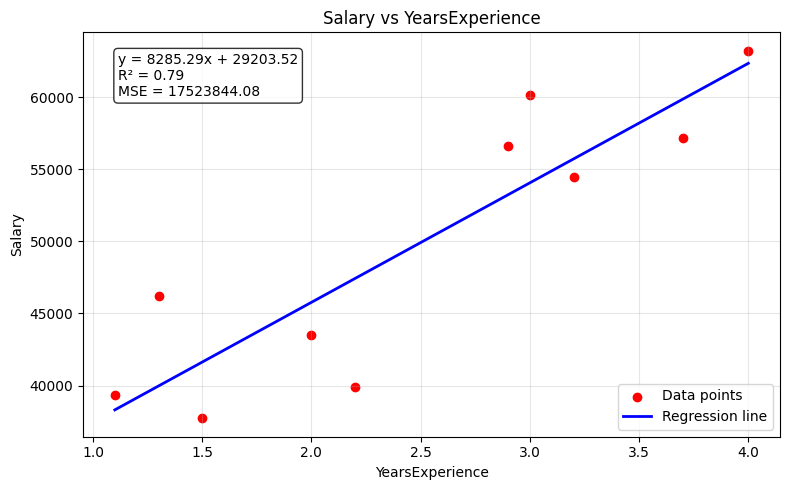

Saved plot: linear_model_python_output.png


In [4]:
plt.figure(figsize=(8, 5))
plt.scatter(data[x_col], data[y_col], color="red", label="Data points")
plt.plot(data[x_col], y_pred, color="blue", linewidth=2, label="Regression line")

annotation = (
    f"y = {slope:.2f}x + {intercept:.2f}\n"
    f"R² = {r2:.2f}\n"
    f"MSE = {mse:.2f}"
)
plt.text(
    0.05,
    0.95,
    annotation,
    transform=plt.gca().transAxes,
    fontsize=10,
    verticalalignment="top",
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.8),
)

plt.title(f"{y_col} vs {x_col}")
plt.xlabel(x_col)
plt.ylabel(y_col)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("linear_model_python_output.png", dpi=150)
plt.show()
print("Saved plot: linear_model_python_output.png")